## Ejercicio Time Series Forecast
Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolinea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

Para ello, se pide:
1. Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?
2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior. Tienes que usar la función rolling() del DataFrame.
3. Comprueba de manera estadística si la serie es o no stationary.
4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary. Acuérdate después del forecast de invertir la transformación.
5. Divide en train y test. Guarda 20 muestras para test.
6. Crea tu primer modelo ARIMA. Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro "m" de la función ARIMA, mediante el cual se establece el seasonality.
7. Representa en una gráfica los datos de test y tus predicciones.
8. Prueba un decission tree y un random forest, a ver qué performance presentan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## 1. Carga datos y representa la serie

In [2]:
df = pd.read_csv("data/AirPassengers.csv")
df.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [3]:
df.head(20)

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
5,1949-06-01,135
6,1949-07-01,148
7,1949-08-01,148
8,1949-09-01,136
9,1949-10-01,119


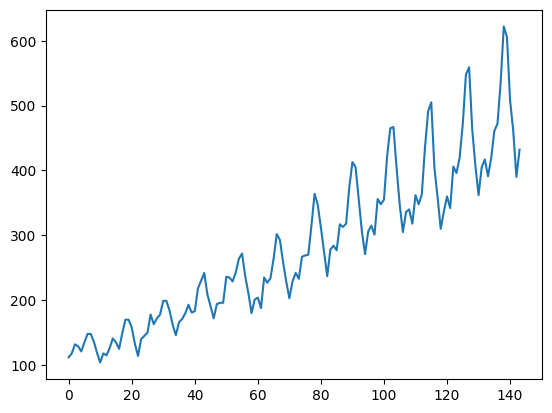

In [4]:
plt.plot(df["value"])

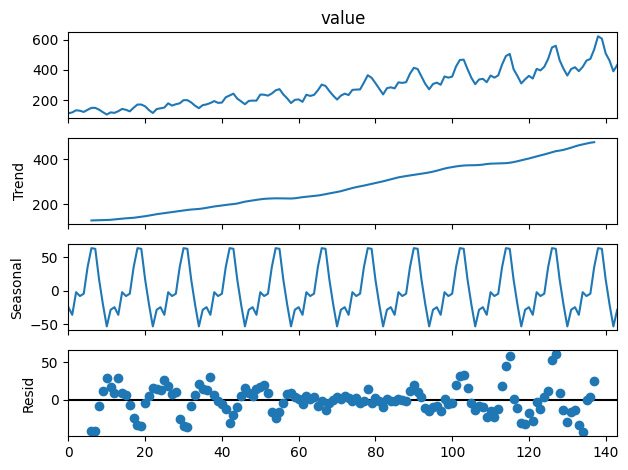

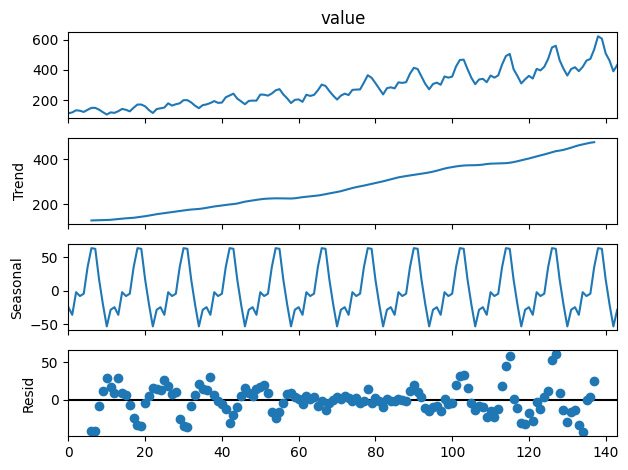

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose


# 2. Realizar la descomposición multiplicativa
# Usamos period=12 porque los datos son mensuales y el ciclo es anual
result = seasonal_decompose(df['value'], period=12)
result.plot()


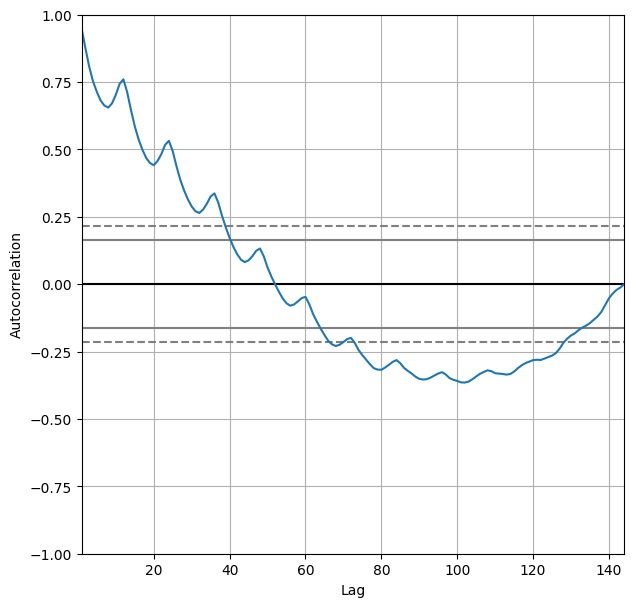

In [7]:
plt.figure(figsize=(7, 7))
pd.plotting.autocorrelation_plot(df['value'])

plt.ylim(-1, 1)
plt.grid(True)
plt.show()

## 2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior

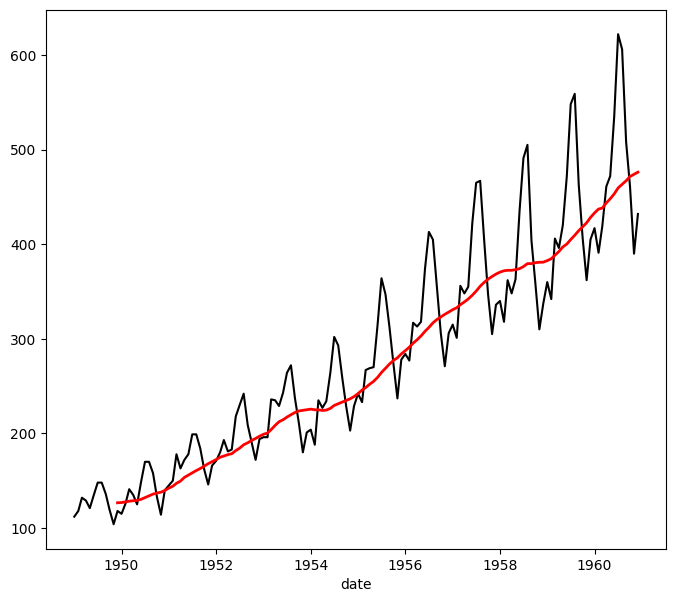

In [8]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

df['rolling_mean'] = df['value'].rolling(window=12).mean()
plt.figure(figsize=(8, 7))

plt.plot(df.index, df['value'], color='black')

plt.plot(df.index, df['rolling_mean'], color='red', linewidth=2)

plt.xlabel('date')
plt.show()

## 3. Comprueba de manera estadística si la serie es o no stationary.

El test estadístico es positivo, lo cual implica que es mucho menos probable que rechacemos la hipótesis nula (no estacionaria).

Al comparar el estadístico ADF con los valores críticos, parece que no podríamos rechazar la hipótesis nula de que la serie temporal no es estacionaria y en consecuencia afirmamos que la serie tiene una estructura que sí que es dependiente del tiempo.

Un valor p por encima del umbral sugiere que no rechazamos la hipótesis nula (no estacionario).

In [9]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    result = adfuller(timeseries)
    
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

test_stationarity(df['value'])

ADF Statistic: 0.815369
p-value: 0.991880
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


## 4. Aplica una transformación logarítmica

In [10]:
df['log_value'] = np.log(df['value'])

In [11]:
df = df.drop('rolling_mean', axis=1)

In [12]:
df

,value,log_value
date,,
1949-01-01,112,4.718499
1949-02-01,118,4.770685
1949-03-01,132,4.882802
1949-04-01,129,4.859812
1949-05-01,121,4.795791
...,...,...
1960-08-01,606,6.406880
1960-09-01,508,6.230481
1960-10-01,461,6.133398


Podemos ver que el valor es mayor que los valores críticos, lo que significa que podemos rechazar la hipótesis nula y, a su vez, que la serie de tiempo no es estacionaria.

Sin embargo nos sigue interesando aplicar la transformación porque conseguimos estabilizar la varianza.

In [13]:
test_stationarity(df['log_value'])

ADF Statistic: -1.717017
p-value: 0.422367
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


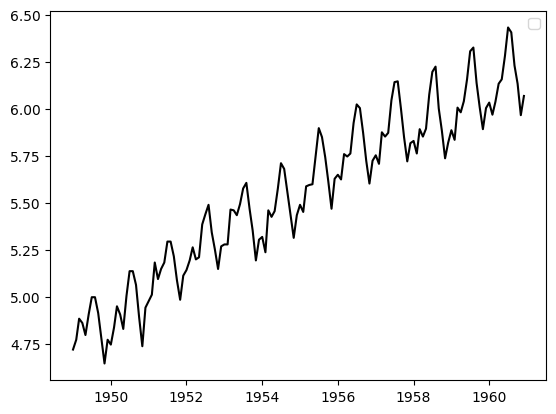

In [14]:
plt.plot(df['log_value'], color='black')
plt.legend()

## 5. Divide en train y test. Guarda 20 muestras para test.

In [15]:
X = df.iloc[:,1:].values
y = df.iloc[:, 0].values

X_train = X[:20]
X_test = X[20:]
y_train = y[:20]
y_test = y[20:]

print("Shape X_train:", X_train.shape)
print("Shape X_test", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:", y_test.shape)

Shape X_train: (20, 1)
Shape X_test (124, 1)
Shape y_train: (20,)
Shape y_test: (124,)


In [16]:
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
model = auto_arima(df['value'], 
                         seasonal=True,   # Cambia a False si tus datos no tienen ciclos
                         m=12,            # Periodicidad: 12 (mensual), 7 (diario), 4 (trimestral)
                         stepwise=True, 
                         trace=True)

# 3. Ver qué parámetros eligió el modelo
print(model.summary())

# 4. Predecir los próximos 10 periodos
print(f"Mejor modelo encontrado: {model.order}")

# 4. Realizar el pronóstico sobre el set de prueba
predictions = model.predict(n_periods=len(test))

# 5. Calcular las métricas de precisión
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test, predictions)

print(f"\n--- Métricas de Evaluación ---")
print(f"MSE:  {mse:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"MAE:  {mae:.5f}")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1020.048, Time=1.37 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.13 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.18 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=1019.935, Time=0.64 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1019.290, Time=0.17 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=1019.546, Time=0.76 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1024.160, Time=0.12 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1017.847, Time=0.14 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1017.914, Time=0.79 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=1018.359, Time=0.75 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=1018.248, Time=1.56 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.07 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.393, Time=0.05 sec
 ARIMA(3,1,1)(0,1,0

NameError: name 'test' is not defined

## 6. Crea tu primer modelo ARIMA

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-211.160, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-203.811, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-205.275, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-206.552, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-204.531, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.26 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.21 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-206.463, Time=0.05 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-228.438, Time=0.16 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-232.458, Time=0.25 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-231.685, Time=0.25 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=-236.639, Time=0.33 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=-216.484, Time=0.20 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=-235.7

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,1,1)[12] intercept   : AIC=-408.447, Time=0.67 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-294.133, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-403.899, Time=0.45 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-357.432, Time=0.33 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-126.477, Time=0.02 sec
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=-415.946, Time=0.52 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=-388.347, Time=0.26 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=-414.037, Time=1.92 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=-409.560, Time=0.68 sec
 ARIMA(1,0,1)(1,1,2)[12] intercept   : AIC=-412.441, Time=2.74 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=-412.579, Time=0.34 sec
 ARIMA(2,0,1)(0,1,1)[12] intercept   : AIC=-415.211, Time=0.49 sec
 ARIMA(1,0,2)(0,1,1)[12] intercept   : AIC=-414.359, Time=0.87 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=-304.397, Time=0.13 sec
 ARIMA(0,0,2)(0,1,1

In [14]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  125
Model:             SARIMAX(2, 0, 0)x(0, 1, [1], 12)   Log Likelihood                 213.390
Date:                              Sun, 03 May 2026   AIC                           -416.780
Time:                                      23:12:15   BIC                           -403.143
Sample:                                  01-01-1949   HQIC                          -411.246
                                       - 05-01-1959                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0197      0.010      2.044      0.041       0.001       0.039
ar.L1          0.6061      0.086      7.086      0.000       0.438       0.774
ar.L2          0.2331      0.089      2.607      0.009       0.058       0.408
ma.S.L12      -0.5596      0.116     -4.817      0.000      -0.787      -0.332
sigma2         0.0013      0.000      7.781      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 5.06
Prob(Q):                              0.97   Prob(JB):                         0.08
Heteroskedasticity (H):               0.41   Skew:                             0.08
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## 7. Representa en una gráfica los datos de test y tus predicciones.

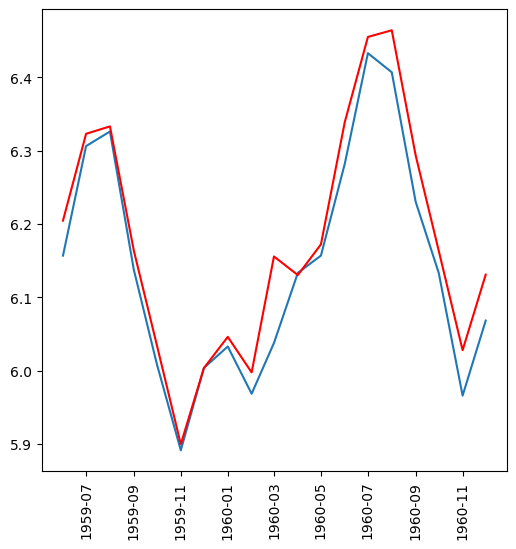

In [16]:
test

date
1959-06-01    6.156979
1959-07-01    6.306275
1959-08-01    6.326149
1959-09-01    6.137727
1959-10-01    6.008813
1959-11-01    5.891644
1959-12-01    6.003887
1960-01-01    6.033086
1960-02-01    5.968708
1960-03-01    6.037871
1960-04-01    6.133398
1960-05-01    6.156979
1960-06-01    6.282267
1960-07-01    6.432940
1960-08-01    6.406880
1960-09-01    6.230481
1960-10-01    6.133398
1960-11-01    5.966147
1960-12-01    6.068426
Name: value, dtype: float64

## 8. Prueba otros modelos, a ver qué performance presentan.

In [18]:
df.head()

,value,t-12,t-11,t-10,t-9,t-8,t-7,t-6,t-5,t-4,t-3,t-2,t-1
date,,,,,,,,,,,,,
1950-01-01,4.744932,4.718499,4.770685,4.882802,4.859812,4.795791,4.905275,4.997212,4.997212,4.912655,4.779123,4.644391,4.770685
1950-02-01,4.836282,4.770685,4.882802,4.859812,4.795791,4.905275,4.997212,4.997212,4.912655,4.779123,4.644391,4.770685,4.744932
1950-03-01,4.948760,4.882802,4.859812,4.795791,4.905275,4.997212,4.997212,4.912655,4.779123,4.644391,4.770685,4.744932,4.836282
1950-04-01,4.905275,4.859812,4.795791,4.905275,4.997212,4.997212,4.912655,4.779123,4.644391,4.770685,4.744932,4.836282,4.948760
1950-05-01,4.828314,4.795791,4.905275,4.997212,4.997212,4.912655,4.779123,4.644391,4.770685,4.744932,4.836282,4.948760,4.905275


Shape X_train: (113, 12)
Shape X_test: (19, 12)
Shape y_train: (113,)
Shape y_test: (19,)


MSE: 0.003950286274393626
RMSE: 0.06285130288541062
MAE: 0.035043466162095575


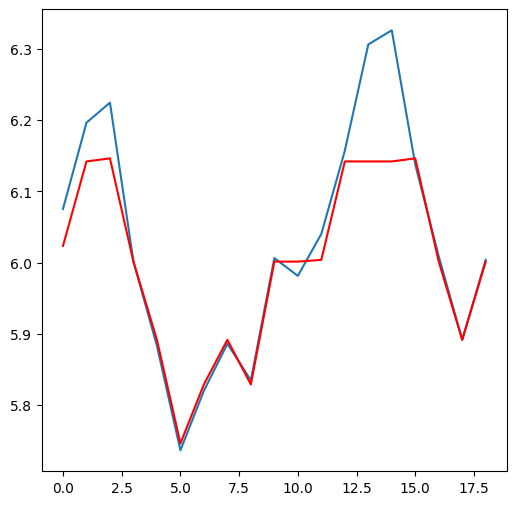